# EDA on Subject Demographics

- Age_at_visit_14Dec2025.csv
- Demographics_14Dec2025.csv
- Socio-Economics_14Dec2025.csv
- Subject_Cohort_History_14Dec2025.csv
- Famiy_History_14Dec2025.csv

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Allow pandas to show all columns
pd.set_option('display.max_columns', None)

In [2]:
# Load master_df
master_df = pd.read_csv('../../Experiment/preprocessing/master_df.csv')

master_df.shape

(4369, 5)

In [3]:
# Count how many unique PATNO are there in master_df
unique_patients = master_df['PATNO'].nunique()
print(f"Total unique patients in master_df: {unique_patients}")

Total unique patients in master_df: 4369


In [ ]:
# Load all data from CSV and print summary statistics
age_at_visit_df = pd.read_csv('../../ppmi_pd/Subject_Demographics/Age_at_visit_14Dec2025.csv')
demographic_df = pd.read_csv('../../ppmi_pd/Subject_Demographics/Demographics_14Dec2025.csv')
socio_economic_df = pd.read_csv('../../ppmi_pd/Subject_Demographics/Socio-Economics_14Dec2025.csv')
cohort_history_df = pd.read_csv('../../ppmi_pd/Subject_Demographics/Subject_Cohort_History_14Dec2025.csv')
family_history_df = pd.read_csv('../../ppmi_pd/Family_History_14Dec2025.csv')

In [5]:
# Create a function to preprocess family_history_df
def preprocess_family_history(df):
    
    # Filter rows where EVENT_ID='SC'
    df_filtered = df[df['EVENT_ID'] == 'SC'].copy()

    # Select relevant columns
    relevant_columns = ['PATNO', 'EVENT_ID', 'ANYFAMPD',
       'BIOMOM', 'BIOMOMPD', 'BIODAD', 'BIODADPD', 'FULSIB', 'FULBRO',
       'FULSIS', 'FULSIBPD', 'FULBROPD', 'FULSISPD', 'HAFSIB', 'PAHAFSIB',
       'MAHAFSIB', 'HAFSIBPD', 'MAHAFSIBPD', 'PAHAFSIBPD', 'MAGPAR',
       'MAGPARPD', 'MAGFATHPD', 'MAGMOTHPD', 'PAGPAR', 'PAGPARPD', 'PAGFATHPD',
       'PAGMOTHPD', 'MATAU', 'MATAUPD', 'PATAU', 'PATAUPD', 'KIDSNUM',
       'KIDSPD', 'DISFAMPD', 'MATCOUS', 'MATCOUSPD', 'PATCOUS', 'PATCOUSPD'
    ]
    
    merged_df = df_filtered[relevant_columns].copy()

    # Merge with master_df with 'PATNO'
    merged_df = pd.merge(master_df, merged_df, on='PATNO', how='left')

    return merged_df

family_history_merged_df = preprocess_family_history(family_history_df)
print(family_history_merged_df.shape)
family_history_merged_df.columns
# family_history_merged_df['EVENT_ID'].unique()

(4369, 42)


Index(['PATNO', 'COHORT', 'COHORT_DEFINITION', 'ENROLL_STATUS', 'ENROLL_AGE',
       'EVENT_ID', 'ANYFAMPD', 'BIOMOM', 'BIOMOMPD', 'BIODAD', 'BIODADPD',
       'FULSIB', 'FULBRO', 'FULSIS', 'FULSIBPD', 'FULBROPD', 'FULSISPD',
       'HAFSIB', 'PAHAFSIB', 'MAHAFSIB', 'HAFSIBPD', 'MAHAFSIBPD',
       'PAHAFSIBPD', 'MAGPAR', 'MAGPARPD', 'MAGFATHPD', 'MAGMOTHPD', 'PAGPAR',
       'PAGPARPD', 'PAGFATHPD', 'PAGMOTHPD', 'MATAU', 'MATAUPD', 'PATAU',
       'PATAUPD', 'KIDSNUM', 'KIDSPD', 'DISFAMPD', 'MATCOUS', 'MATCOUSPD',
       'PATCOUS', 'PATCOUSPD'],
      dtype='object')

In [6]:
# Create function that create new demographic_df by choosing only relevant columns
def create_relevant_demographic_df(demographic_df):

    # Filter rows where EVENT_ID='SC'
    df_filtered = demographic_df[demographic_df['EVENT_ID'] == 'SC'].copy()

    relevant_columns = [
        'PATNO', 'EVENT_ID', 'INFODT', 'AFICBERB', 'ASHKJEW', 'BASQUE', 'SEX',
        'HOWLIVE', 'GAYLES', 'HETERO', 'BISEXUAL', 'PANSEXUAL', 'ASEXUAL', 'OTHSEXUALITY',
        'HANDED', 'HISPLAT', 'RAASIAN', 'RABLACK', 'RAHAWOPI', 'RAINDALS', 'RANOS', 'RAWHITE', 'RAUNKNOWN'
    ]

    # Return new demographic_df with only relevant columns
    merged_df = df_filtered[relevant_columns].copy()

    # Merge with master_df with 'PATNO'
    merged_df = pd.merge(master_df, merged_df, on='PATNO', how='left')

    return merged_df

demographic_df = create_relevant_demographic_df(demographic_df)
print(demographic_df.shape)
demographic_df.columns

(4369, 27)


Index(['PATNO', 'COHORT', 'COHORT_DEFINITION', 'ENROLL_STATUS', 'ENROLL_AGE',
       'EVENT_ID', 'INFODT', 'AFICBERB', 'ASHKJEW', 'BASQUE', 'SEX', 'HOWLIVE',
       'GAYLES', 'HETERO', 'BISEXUAL', 'PANSEXUAL', 'ASEXUAL', 'OTHSEXUALITY',
       'HANDED', 'HISPLAT', 'RAASIAN', 'RABLACK', 'RAHAWOPI', 'RAINDALS',
       'RANOS', 'RAWHITE', 'RAUNKNOWN'],
      dtype='object')

In [7]:
# Create function that create new socio-economic_df by choosing only relevant columns
def create_relevant_socio_economic_df(socio_economic_df):

    # Filter rows where EVENT_ID='SC'
    df_filtered = socio_economic_df[socio_economic_df['EVENT_ID'] == 'SC'].copy()

    relevant_columns = [
        'PATNO', 'INFODT','EDUCYRS']

    # Return new demographic_df with only relevant columns
    merged_df = df_filtered[relevant_columns].copy()

    # Merge with master_df with 'PATNO'
    merged_df = pd.merge(master_df, merged_df, on='PATNO', how='left')

    return merged_df

socio_economic_df = create_relevant_socio_economic_df(socio_economic_df)
print(socio_economic_df.shape)
socio_economic_df.columns

(4369, 7)


Index(['PATNO', 'COHORT', 'COHORT_DEFINITION', 'ENROLL_STATUS', 'ENROLL_AGE',
       'INFODT', 'EDUCYRS'],
      dtype='object')

In [12]:
# Create function that create new age_at_visit_df by choosing only relevant columns
def create_relevant_age_at_visit_df(age_at_visit_df):
    
    # Filter only relevant rows
    relevant_columns = [
        'PATNO', 'EVENT_ID', 'AGE_AT_VISIT']

    # Return new demographic_df with only relevant columns
    age_at_visit_df = age_at_visit_df[relevant_columns].copy()

    # Merge age_at_visit_df to master_df on 'PATNO'
    merged_df = pd.merge(master_df, age_at_visit_df, on='PATNO', how='left')

    return merged_df

age_at_visit_df = create_relevant_age_at_visit_df(age_at_visit_df)
print(age_at_visit_df.shape)
age_at_visit_df.columns

(39188, 7)


Index(['PATNO', 'COHORT', 'COHORT_DEFINITION', 'ENROLL_STATUS', 'ENROLL_AGE',
       'EVENT_ID', 'AGE_AT_VISIT'],
      dtype='object')

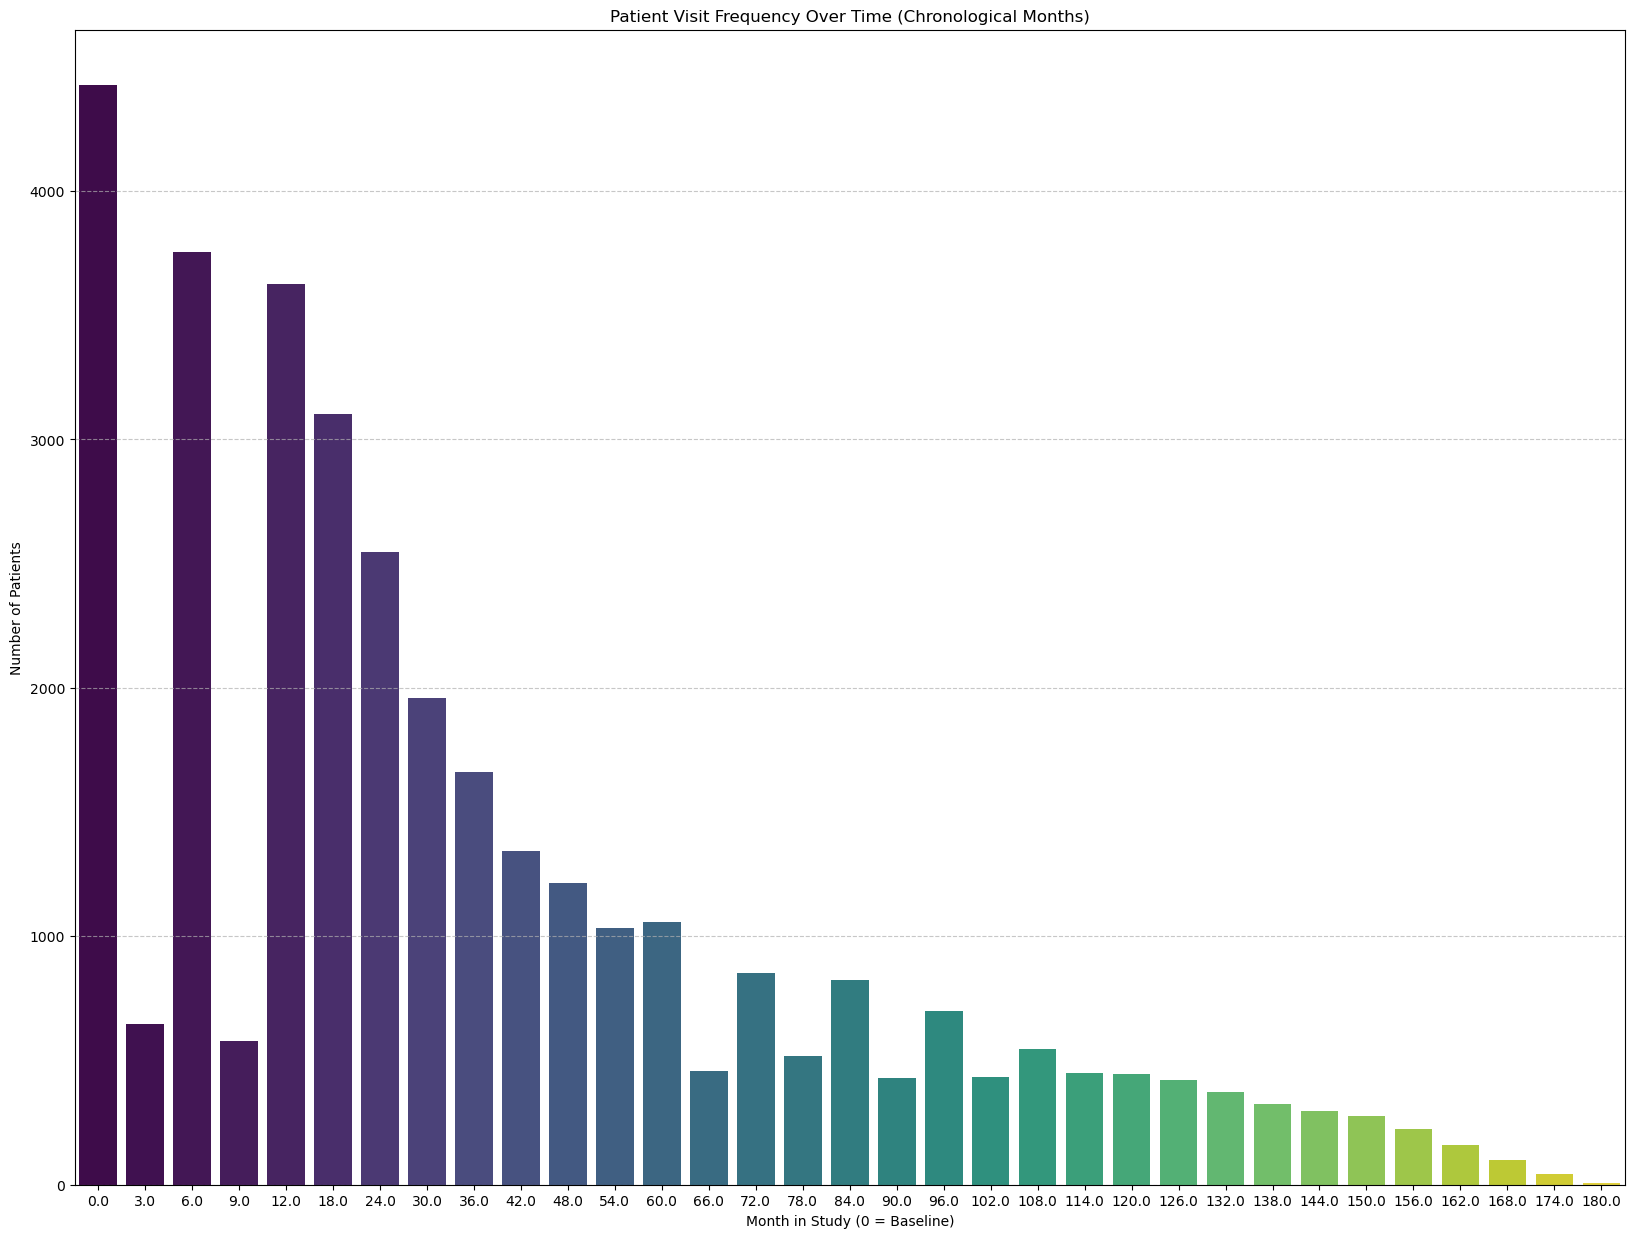

In [24]:
# Function to map EVENT_ID to Month using code list annotated CSV
def get_ppmi_event_months(code_list_path, mod_name='_ALL'):
    """
    Dynamically maps EVENT_ID to Month using the PPMI Code List.
    
    Args:
        code_list_path (str): Path to 'Code_List_-__Annotated__14Dec2025.csv'.
        mod_name (str): The module to target (e.g., '_ALL', 'PET_ACQUISITION').
        
    Returns:
        dict: Mapping of {EVENT_ID_CODE: Month_Number}
    """
    codes = pd.read_csv(code_list_path)
    # Filter for EVENT_ID items
    events = codes[codes['ITM_NAME'] == 'EVENT_ID']
    
    # Target specific module, fallback to '_ALL' if not found
    subset = events[events['MOD_NAME'] == mod_name]
    if subset.empty and mod_name != '_ALL':
        subset = events[events['MOD_NAME'] == '_ALL']
    
    mapping = {}
    for _, row in subset.iterrows():
        code = str(row['CODE'])
        decode = str(row['DECODE']).upper()
        
        # Skip Screening codes
        if 'SC' in code.upper():
            continue
        
        # 1. Look for "Month X" or "X Month" using regex
        month_match = re.search(r'MONTH\s*(\d+)', decode)
        if not month_match:
            month_match = re.search(r'(\d+)\s*MONTH', decode)
            
        if month_match:
            mapping[code] = int(month_match.group(1))
        # 2. Handle Keywords for start points
        elif 'BASELINE' in decode or decode == 'BL':
            mapping[code] = 0
        # 3. Handle Phone Visits (P-codes)
        elif code.startswith('P') and code[1:].isdigit():
            mapping[code] = int(code[1:])
            
    return mapping

def prepare_df_for_chronological_plot(df, event_mapping):
    """
    Adds a 'MONTH' column to a dataframe and sorts it chronologically.
    """
    df = df.copy()
    df['MONTH'] = df['EVENT_ID'].map(event_mapping)
    
    # Drop rows that don't have a chronological month (e.g., LOG, GMU, ED)
    df = df.dropna(subset=['MONTH'])
    
    return df.sort_values('MONTH')

# Usage Example:
# Create the mapping from code_list_annotated CSV
mapping = get_ppmi_event_months('../../ppmi_pd/Data___Databases/Code_List_-__Annotated__14Dec2025.csv')

# Apply to your data (e.g., your master_merge or moca_df)
# Let's assume you have a dataframe 'my_data' with an 'EVENT_ID' column
plot_df = prepare_df_for_chronological_plot(age_at_visit_df, mapping)

# Plot Frequency/Count
plt.figure(figsize=(20, 15))
sns.countplot(data=plot_df, x='MONTH', hue='MONTH', palette='viridis', legend=False)

plt.title('Patient Visit Frequency Over Time (Chronological Months)')
plt.xlabel('Month in Study (0 = Baseline)')
plt.ylabel('Number of Patients')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Patient Counts per Major Milestone (Total):
   Month  Total_Patient_Count
0    0.0                 4362
1    3.0                  648
2    6.0                 3743
3    9.0                  579
4   12.0                 3540
5   18.0                 3080
6   24.0                 2517
7   30.0                 1954
8   36.0                 1645
9   42.0                 1341


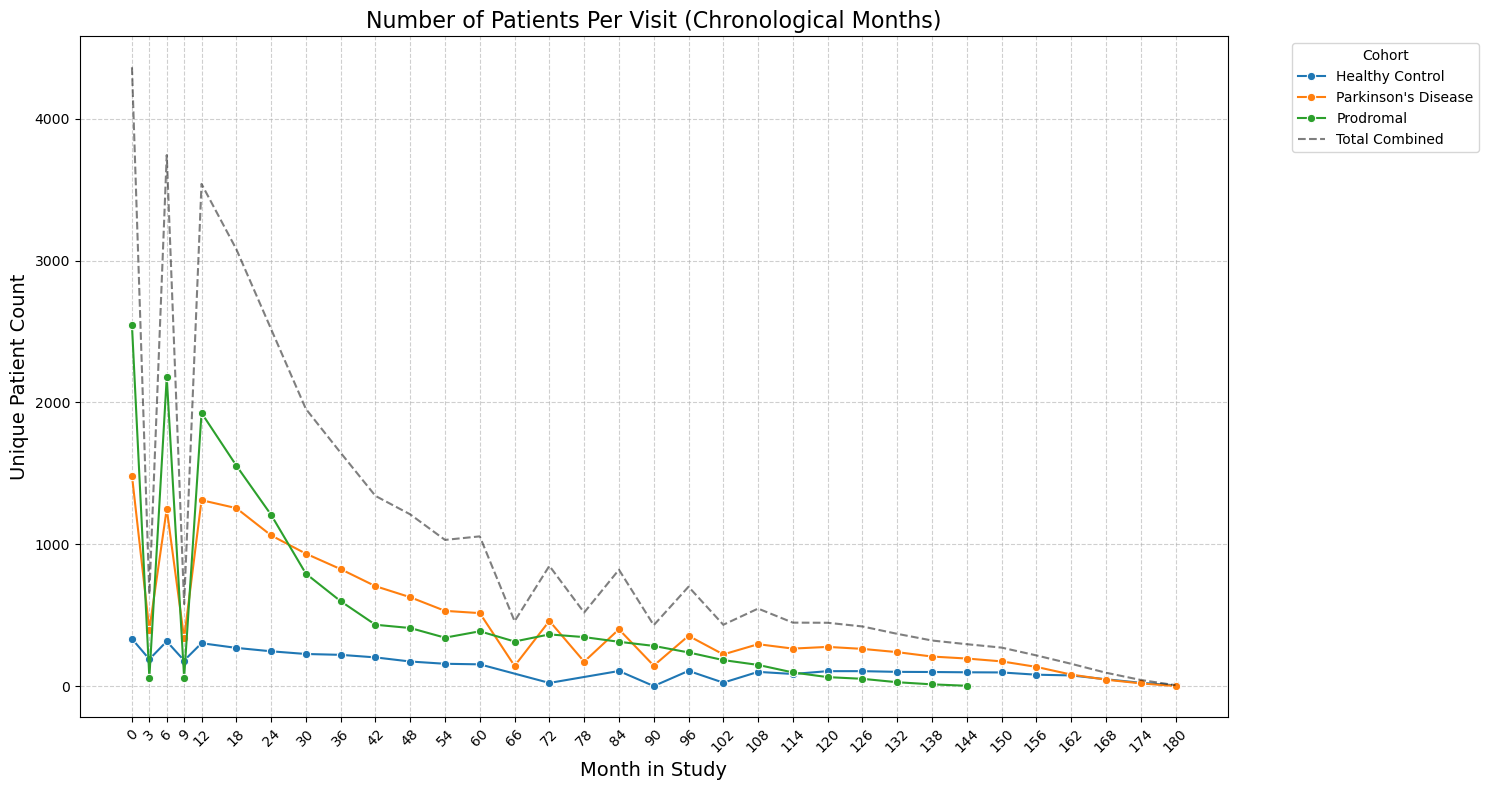

In [22]:
# Function to map number of unique patient to Month using code list annotated CSV
# Apply mapping to age_at_visit_df
age_at_visit_df['MONTH'] = age_at_visit_df['EVENT_ID'].map(mapping)

# Drop rows with no chronological month (or filtered out SC)
plot_df = age_at_visit_df.dropna(subset=['MONTH']).copy()

# Sort by month for the x-axis
plot_df = plot_df.sort_values('MONTH')

# Group by Month and Cohort to get patient counts
# We count unique PATNO per month and cohort
patient_counts = plot_df.groupby(['MONTH', 'COHORT_DEFINITION'])['PATNO'].nunique().reset_index()
patient_counts.columns = ['Month', 'Cohort', 'Patient_Count']

# Total patients per month (all cohorts combined)
total_counts = plot_df.groupby('MONTH')['PATNO'].nunique().reset_index()
total_counts.columns = ['Month', 'Total_Patient_Count']

# Plotting
plt.figure(figsize=(15, 8))
sns.lineplot(data=patient_counts, x='Month', y='Patient_Count', hue='Cohort', marker='o')
plt.plot(total_counts['Month'], total_counts['Total_Patient_Count'], color='black', linestyle='--', label='Total Combined', alpha=0.5)

plt.title('Number of Patients Per Visit (Chronological Months)', fontsize=16)
plt.xlabel('Month in Study', fontsize=14)
plt.ylabel('Unique Patient Count', fontsize=14)
plt.legend(title='Cohort', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(plot_df['MONTH'].unique(), rotation=45)
plt.tight_layout()
# plt.savefig('patients_per_visit.png')

# Show the table of counts for the response
print("Patient Counts per Major Milestone (Total):")
print(total_counts.head(10))

count    39187.000000
mean        66.528749
std          9.082552
min         26.400000
25%         61.600000
50%         67.200000
75%         72.500000
max         98.100000
Name: AGE_AT_VISIT, dtype: float64


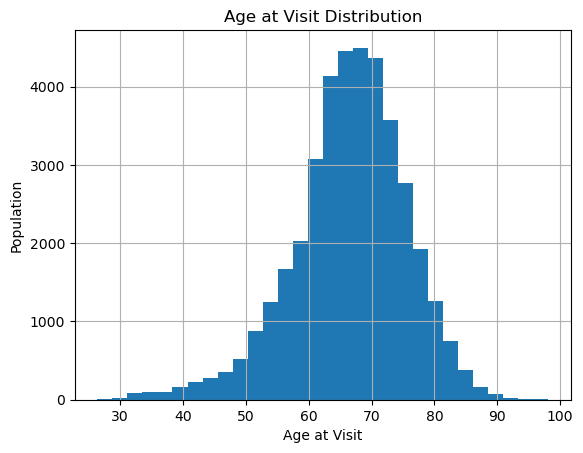

In [23]:
# Plot age distribution
print(age_at_visit_df['AGE_AT_VISIT'].describe())
age_at_visit_df['AGE_AT_VISIT'].hist(bins=30)
plt.title('Age at Visit Distribution')
plt.xlabel('Age at Visit')
plt.ylabel('Population')
plt.show()

In [19]:
# How to trim demographics?
# What columns to keep in master_df?
# Moving forward, what should be the timeline of the gradient? base on event id or month? does the actual date on INFODT matter?